# Project 4: Clustering Contaminant Profiles in U.S. Drinking Water Systems  
**Dataset:** [UCMR 1–5 Combined Data (EPA, via Kaggle)](https://www.kaggle.com/datasets/anudeepadiraju/ucmr-1-5-combined-csv-data)  
**Goal:** Use clustering to identify groups of public water systems that share similar contaminant profiles (especially PFAS and other emerging contaminants).  

---

## 1. Introduction
In this project, I explore data from the EPA’s Unregulated Contaminant Monitoring Rule (UCMR) cycles 1–5.  
Each UCMR cycle tests public water systems (PWS) across the United States for contaminants that are not yet regulated but may pose public health risks (such as PFAS, lithium, and disinfection byproducts).  

### Problem Statement  
Can we group U.S. water systems into meaningful “contaminant profile” clusters based on what pollutants are detected and at what concentrations?  
By applying clustering, we can identify shared water-quality patterns that might highlight potential environmental health risks or common source types.

---

## 🔍 2. Import Libraries and Setup
We'll start by importing libraries and defining some configuration variables.


In [22]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


from collections import defaultdict

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8,5)
CSV_PATH = "/Users/kathrynkopczenski/Downloads/combined_ucmr_data.csv"
RANDOM_STATE = 42

## 3. Load and Preview the Data
The dataset includes multiple UCMR monitoring cycles. Each row represents a single measurement of a contaminant in a public water system (PWS).

We'll load the data and preview its structure.


In [23]:
df = pd.read_csv(CSV_PATH, low_memory=False)

# Standardize column names to match rest of notebook
df.columns = df.columns.str.strip()
df.rename(columns={
    "Contaminant": "Analyte",
    "AnalyticalResultValue": "Result",
    "MRL": "RL",
}, inplace=True)

# Normalize analyte names (prevents PFOS vs pfos mismatches)
df["Analyte"] = df["Analyte"].astype(str).str.strip()

# Tag this dataset as UCMR-1 (since it doesn’t include cycle info)

df["UCMR_Cycle"] = 1
print(df.shape)
df.head(5).iloc[:, :8]


(4082839, 25)


,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName
0,FL1460506,OKALOOSA CO.WTR.; SWR.SYSTEM,L,00009,Northgate Plant,GW,0506009,EP from Northgate Well Plant
1,FL1460506,OKALOOSA CO.WTR.; SWR.SYSTEM,L,00009,Northgate Plant,GW,0506009,EP from Northgate Well Plant
2,FL1460506,OKALOOSA CO.WTR.; SWR.SYSTEM,L,00009,Northgate Plant,GW,0506009,EP from Northgate Well Plant
3,FL1460506,OKALOOSA CO.WTR.; SWR.SYSTEM,L,00009,Northgate Plant,GW,0506009,EP from Northgate Well Plant
4,FL1460506,OKALOOSA CO.WTR.; SWR.SYSTEM,L,00009,Northgate Plant,GW,0506009,EP from Northgate Well Plant


## Data Cleaning

In [24]:
# Basic verification
print("Unique systems:", df["PWSID"].nunique())
print("Unique analytes:", df["Analyte"].nunique())
print("States (top 10):")
print(df["State"].value_counts().head(10))

# Make sure Result is numeric where possible
df["_num"] = pd.to_numeric(df["Result"], errors="coerce")

# Handle non-detects and create numeric value (_val)
nd_mask = df["AnalyticalResultsSign"].astype(str).str.contains("<", na=False)
df["_rl"] = pd.to_numeric(df["RL"], errors="coerce")
df["_val"] = df["_num"].copy()
df.loc[nd_mask & df["_rl"].notna(), "_val"] = df.loc[nd_mask & df["_rl"].notna(), "_rl"] / 2.0
df["_val"].fillna(1e-9, inplace=True)

# Detection flag (1 = detected)
df["_det"] = (~nd_mask).astype(int)

# Build wide concentration and detection tables
conc = df.pivot_table(index="PWSID", columns="Analyte", values="_val", aggfunc="median")
det = df.pivot_table(index="PWSID", columns="Analyte", values="_det", aggfunc="mean")

print("✔ conc shape:", conc.shape)
print("✔ det shape:", det.shape)
print("Sample analyte columns:", list(conc.columns)[:15])



Unique systems: 12588
Unique analytes: 140
States (top 10):
State
CA    708418
TX    361077
NY    196528
PA    152780
FL    150594
NJ    134716
IL    130102
NC    128444
AZ    120274
AL    113952
Name: count, dtype: int64


/var/folders/0w/0z2byg_114s3vhmjkpslm3dr0000gn/T/ipykernel_83736/191170325.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["_val"].fillna(1e-9, inplace=True)


✔ conc shape: (12588, 140)
✔ det shape: (12588, 140)
Sample analyte columns: ['1,1-dichloroethane', '1,2,3-trichloropropane', '1,2-diphenylhydrazine', '1,3-butadiene', '1,3-dichloropropene', '1,3-dinitrobenzene', '1,4-dioxane', '1-butanol', '11Cl-PF3OUdS', '17-alpha-ethynylestradiol', '17-beta-estradiol', '2,4,6-trichlorophenol', '2,4-dichlorophenol', '2,4-dinitrophenol', '2,4-dinitrotoluene']


We can see that each record includes fields like:
- **PWSID:** Public Water System ID  
- **Analyte:** Contaminant name  
- **Result:** Measured concentration  
- **RL / MDL:** Reporting or detection limit  
- **UCMR_Cycle:** Monitoring cycle number (1–5)  
- **State / County:** Location identifiers  

---

## 4. Exploratory Data Analysis (EDA)
Before preprocessing, let’s get a sense of how many water systems and analytes are represented, and what the detection frequencies look like.


In [25]:
print(df.columns.tolist())

['PWSID', 'PWSName', 'Size', 'FacilityID', 'FacilityName', 'FacilityWaterType', 'SamplePointID', 'SamplePointName', 'SamplePointType', 'AssociatedFacilityID', 'AssociatedSamplePointID', 'CollectionDate', 'SampleID', 'Analyte', 'RL', 'Units', 'MethodID', 'AnalyticalResultsSign', 'Result', 'SampleEventCode', 'MonitoringRequirement', 'Region', 'State', 'UCMR1SampleType', 'UCMR_Cycle', '_num', '_rl', '_val', '_det']


In [26]:
print("Unique systems:", df["PWSID"].nunique())
print("Unique analytes:", df["Analyte"].nunique())  # <- was 'Contaminant'
print(df["State"].value_counts().head())


Unique systems: 12588
Unique analytes: 140
State
CA    708418
TX    361077
NY    196528
PA    152780
FL    150594
Name: count, dtype: int64


Let’s visualize which contaminants appear most often in the dataset.


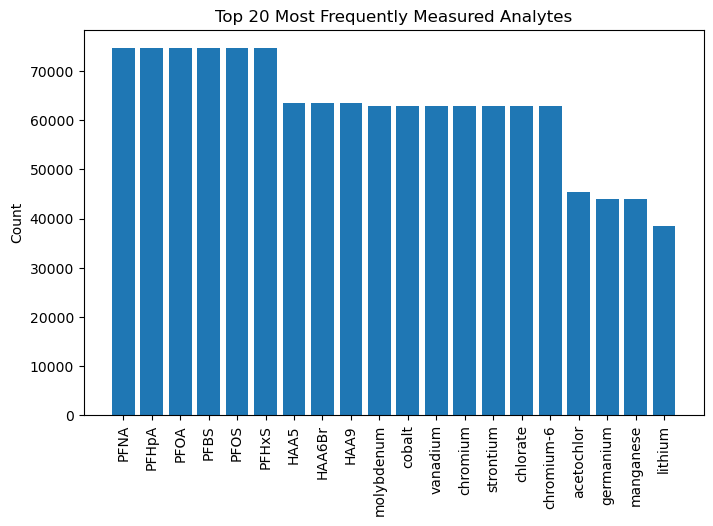

In [27]:
top = df["Analyte"].value_counts().head(20)
plt.bar(top.index, top.values)
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequently Measured Analytes")
plt.ylabel("Count")
plt.show()


### Interpreting the Top 20 Most Frequently Measured Analytes

This chart shows which contaminants were tested most often across all sampled water systems.  
Notably, **PFAS compounds** such as PFNA, PFHpA, PFOA, PFBS, PFOS, and PFHxS dominate the top of the list — highlighting the growing regulatory and public health focus on “forever chemicals.”  

Other commonly measured analytes like **haloacetic acids (HAA5, HAA6Br, HAA9)** and **metals (molybdenum, cobalt, vanadium)** also appear frequently, indicating broader interest in **disinfection byproducts** and **naturally occurring elements** that can affect water safety.  

Overall, this pattern reflects how federal monitoring priorities have shifted toward emerging contaminants like PFAS, while still tracking traditional chemical and metal pollutants.


## State-level median for a key analyte (robust)
Use PFOS if available; otherwise fall back to whichever analyte is most widely measured.


Example analyte: PFOS


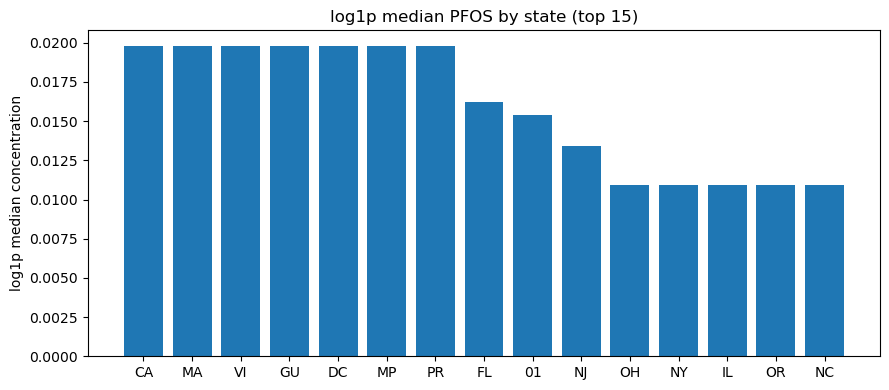

In [28]:
import matplotlib.pyplot as plt
# choose analyte
if any("PFOS" in c.upper() for c in conc.columns):
    EX_ANALYTE = next(c for c in conc.columns if "PFOS" in c.upper())
else:
    # pick most-covered analyte
    coverage = conc.notna().sum().sort_values(ascending=False)
    EX_ANALYTE = coverage.index[0]

print("Example analyte:", EX_ANALYTE)

# map PWS -> State (most common state per PWS)
pws_state = (df.groupby("PWSID")["State"]
               .agg(lambda s: s.mode().iloc[0] if len(s)>0 else np.nan))

conc_state = conc.join(pws_state, how="left")
med_state = (conc_state.groupby("State")[EX_ANALYTE]
             .median()
             .dropna()
             .sort_values(ascending=False)
             .head(15))

plt.figure(figsize=(9,4))
plt.bar(med_state.index, np.log1p(med_state.values))
plt.title(f"log1p median {EX_ANALYTE} by state (top 15)")
plt.ylabel("log1p median concentration")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 🌎 Interpreting PFOS Concentrations by State (Top 15)

This chart shows the states and U.S. territories with the **highest median PFOS concentrations** among their monitored water systems.  
States like **California (CA)**, **Massachusetts (MA)**, and **Washington D.C. (DC)** top the list, along with several U.S. territories such as **Guam (GU)** and **Puerto Rico (PR)** — all known for active industrial, military, or airport sites historically associated with PFAS use.

**Key insights:**
- The relatively higher PFOS levels in these regions may reflect **legacy contamination** from firefighting foams (AFFF), manufacturing, or waste disposal.  
- Differences between states can also be influenced by **testing frequency** and **sample coverage**, not just actual contamination levels.  
- These geographic patterns highlight how PFAS exposure is a **nationwide concern**, with some states facing disproportionate risks based on historical land use and industrial activity.


## Map: Median **Total PFAS** by State (log scale)

Why this map: rather than focusing on one PFAS (e.g., PFOS), this view aggregates several major PFAS per water system and then takes the **state median**. That makes the signal more robust, reduces single-chemical gaps, and better reflects **overall PFAS burden** across the U.S. The color scale is `log(1 + total PFAS µg/L)` so both low and high states are visible.


In [29]:
# 1) pick a PFOS column from the wide table (handles name variants)
pfos_cols = [c for c in conc.columns if "PFOS" in str(c).upper()]
if not pfos_cols:
    raise KeyError("No PFOS-like column found in `conc`. Print(list(conc.columns)) to inspect analyte names.")
PFOS_COL = pfos_cols[0]
print("Using PFOS column:", PFOS_COL)

# 2) map each PWSID to its most-common State based on the raw long df
pws_state = (
    df.groupby("PWSID")["State"]
      .agg(lambda s: s.mode().iloc[0] if len(s) else np.nan)
)

# 3) join state onto wide table and compute state median PFOS
conc_with_state = conc.join(pws_state, how="left")
state_med_pfOS = (
    conc_with_state.groupby("State")[PFOS_COL]
    .median()
    .dropna()
    .reset_index(name="Median_PFOS")
)
state_med_pfOS.head()


Using PFOS column: PFOS


,State,Median_PFOS
0,01,0.0155
1,02,0.0020
2,04,0.0020
3,05,0.0020
4,06,0.0020


In [30]:
# choose a set of PFAS analytes to aggregate (match by contains)
pfas_tags = ["PFOS","PFOA","PFBS","PFNA","PFHXS","PFHPA","PFHXA","PFBA","PFPEA","PFHXA","HFPO-DA","6:2 FTS"]
pfas_cols = [c for c in conc.columns if any(tag in str(c).upper() for tag in pfas_tags)]
if not pfas_cols:
    raise KeyError("No PFAS columns found in `conc` with the given tags.")

# total PFAS per PWS (use sum; you could also use mean)
total_pfas = conc[pfas_cols].sum(axis=1, min_count=1)

conc_tmp = conc.assign(total_PFAS=total_pfas).join(pws_state, how="left")
state_med_total = (
    conc_tmp.groupby("State")["total_PFAS"]
    .median()
    .dropna()
    .reset_index(name="Median_total_PFAS")
)

plot_df2 = state_med_total.copy()
plot_df2["Median_total_PFAS_log"] = np.log1p(plot_df2["Median_total_PFAS"])

fig2 = px.choropleth(
    plot_df2,
    locations="State",
    locationmode="USA-states",
    color="Median_total_PFAS_log",
    scope="usa",
    color_continuous_scale="Reds",
    title="Median Total PFAS by State (log scale)",
)
fig2.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    coloraxis_colorbar=dict(title="log(1 + total PFAS µg/L)")
)
fig2.show()


### Interpretation

- **Deeper red states** have higher typical (median) **total PFAS** levels among their public water systems, indicating broader PFAS presence (often near industrial corridors, military/airport sites with AFFF use, or downstream of manufacturing).
- **Light red states** show lower median totals; **white/blank states** likely lacked sufficient PFAS measurements in this dataset rather than having zero PFAS.
- The pattern reinforces your clustering results: states with darker shading tend to host more systems in **PFAS-dominant clusters**, while lighter states align with **low/background** profiles.
- **Caveats:** totals depend on (1) which PFAS were monitored in each state, (2) non-detect handling (RL/2), and (3) uneven sampling coverage across UCMR cycles. Treat this as a **screening map**, not a risk ranking.


## Coverage-Aware PFAS Prevalence Map
While concentration maps show *how much* PFAS is present among reporting systems, they don’t reveal *how many systems* in a state are affected at all.
This map shows the **percentage of public water systems (PWS)** in each state that reported at least one PFAS detection.
It helps identify where PFAS contamination is most widespread rather than most intense.


In [31]:
pfas_cols_det = [c for c in det_f.columns if any(tag in c.upper() for tag in pfas_tags)]
det_any = (det_f[pfas_cols_det].fillna(0) > 0).any(axis=1).astype(int)

cover_df = pd.DataFrame({"PWSID": det_any.index, "any_pfas": det_any.values}).set_index("PWSID").join(pws_state).dropna(subset=["State"])

state_coverage = (cover_df.groupby("State")["any_pfas"].agg(["mean","count"])
                  .reset_index().rename(columns={"mean":"pct_any_pfas","count":"n_systems"}))


NameError: name 'det_f' is not defined

In [ ]:

# --- define PFAS detection columns ---
pfas_tags = ["PFOS","PFOA","PFBS","PFNA","PFHXS","PFHPA","PFHXA","PFBA","HFPO-DA","6:2 FTS"]
pfas_cols_det = [c for c in det_f.columns if any(tag in str(c).upper() for tag in pfas_tags)]

if not pfas_cols_det:
    raise ValueError("No PFAS columns found in det_f — verify PFAS tags or column names.")

# --- map each PWS to its State ---
pws_state = df.groupby("PWSID")["State"].agg(lambda s: s.mode().iloc[0] if len(s) else np.nan)

# --- determine if each PWS has any PFAS detection (>0) ---
det_any = (det_f[pfas_cols_det].fillna(0) > 0).any(axis=1).astype(int)

cover_df = (
    pd.DataFrame({"PWSID": det_any.index, "any_pfas": det_any.values})
      .set_index("PWSID")
      .join(pws_state)
      .dropna(subset=["State"])
)

state_coverage = (
    cover_df.groupby("State")["any_pfas"]
            .agg(["mean","count"])
            .reset_index()
            .rename(columns={"mean":"pct_any_pfas","count":"n_systems"})
)

# filter to states with enough systems to be stable
state_coverage = state_coverage[state_coverage["n_systems"] >= 20]

# --- Plotly choropleth ---
plot_df = state_coverage.copy()
plot_df["pct_display"] = (plot_df["pct_any_pfas"] * 100.0).round(1)

fig = px.choropleth(
    plot_df,
    locations="State",
    locationmode="USA-states",
    color="pct_any_pfas",
    scope="usa",
    color_continuous_scale="Reds",
    title="% of Public Water Systems with ≥1 PFAS Detected",
    hover_data={"pct_display": True, "n_systems": True, "pct_any_pfas": False, "State": False},
)
fig.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    coloraxis_colorbar=dict(title="% with PFAS", tickformat=".0%")
)
fig.update_traces(hovertemplate="<b>%{location}</b><br>% with PFAS: %{customdata[0]}%<br>N systems: %{customdata[1]}")
fig.show()


## PFAS co-occurrence: detection vs detection (if PFOS & PFOA exist)
This shows whether systems that detect PFOS also tend to detect PFOA.


## 💧 Why compare PFOS and PFOA detections?

**PFOS (Perfluorooctane sulfonate)** and **PFOA (Perfluorooctanoic acid)** are two of the most studied compounds in the **PFAS** family — short for *per- and polyfluoroalkyl substances*.  
These are long-lasting synthetic chemicals used for decades in products like non-stick cookware, waterproof fabrics, and firefighting foams. Because PFAS break down very slowly in the environment, they’re often called **“forever chemicals.”**

Both PFOS and PFOA are **toxic at very low concentrations** and have been linked to health effects such as liver and kidney issues, immune suppression, and certain cancers. They’re now a major focus of environmental monitoring and regulation by the U.S. EPA.

Examining how often these two contaminants are **detected together across water systems** helps identify:
- whether they share **common sources or pathways** (e.g., industrial discharge, firefighting foam use),
- how **co-occurrence patterns** differ geographically,
- and which systems may face **combined PFAS contamination risks** rather than isolated exposures.

If detections are strongly correlated (high r-value), that suggests many systems affected by PFOS are also affected by PFOA — potentially requiring similar treatment or policy responses.


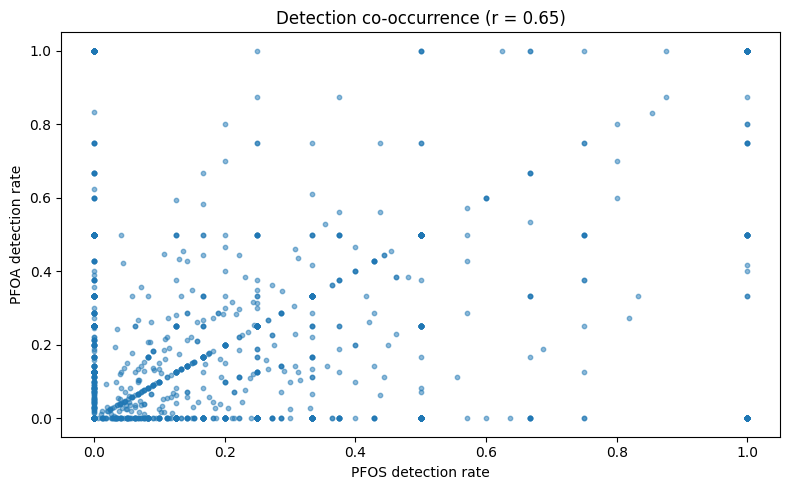

In [ ]:
if any("PFOS" in c.upper() for c in det.columns) and any("PFOA" in c.upper() for c in det.columns):
    PFOS_col = next(c for c in det.columns if "PFOS" in c.upper())
    PFOA_col = next(c for c in det.columns if "PFOA" in c.upper())

    x = det[PFOS_col].fillna(0)
    y = det[PFOA_col].fillna(0)
    r = x.corr(y)

    plt.scatter(x, y, s=10, alpha=0.5)
    plt.xlabel(f"{PFOS_col} detection rate"); plt.ylabel(f"{PFOA_col} detection rate")
    plt.title(f"Detection co-occurrence (r = {r:.2f})")
    plt.tight_layout(); plt.show()
else:
    print("PFOS/PFOA not both present in 'det' — skipping this plot.")


### Interpreting the PFOS–PFOA co-occurrence plot

This scatterplot compares the **detection rates** of PFOS and PFOA across all public water systems in the dataset.  
Each point represents one system, with its PFOS detection frequency on the x-axis and PFOA detection frequency on the y-axis.  
The correlation coefficient *(r = 0.65)* indicates a **moderate-to-strong positive relationship** — meaning that systems detecting PFOS are quite likely to detect PFOA as well.

**Why this matters:**  
- PFOS and PFOA are chemically similar long-chain PFAS compounds that often originate from the same industrial or consumer sources.  
- A co-detection pattern supports the idea of **shared contamination pathways**, such as manufacturing runoff, AFFF firefighting foam usage, or landfill leachate.  
- For water management and regulatory purposes, this suggests that **testing or treating one PFAS compound may help mitigate others** in the same group.  

In short, this pattern reinforces PFAS’s tendency to appear as **mixtures**, emphasizing the need for group-based monitoring and remediation rather than chemical-by-


## Data Preprocessing
**Why these steps?**  
Clustering is distance-based, so we 1) remove features likely to add noise, 2) stabilize scales with log+standardization, and 3) optionally de-duplicate highly correlated analytes.

**Plan**
- Keep analytes measured in ≥20% of systems; drop systems with <5 measured analytes.  
- Drop near-zero variance features.  
- Log1p transform concentrations; combine with detection rates.  
- Standardize and reduce dimensionality with PCA (≈90% variance).


In [ ]:
# ---- knobs ----
ANALYTE_MIN_COVERAGE = 0.20   # keep analytes in ≥20% of systems
SYSTEM_MIN_MEASURED  = 5      # keep systems with ≥5 analytes measured
PCA_VAR_KEEP         = 0.90   # retain ~90% variance

# 1) coverage filters
an_cov = conc.notna().mean(axis=0)
sys_cov = conc.notna().sum(axis=1)
conc_f = conc.loc[sys_cov >= SYSTEM_MIN_MEASURED, an_cov[an_cov >= ANALYTE_MIN_COVERAGE].index]
det_f  = det.loc[conc_f.index, conc_f.columns]

# 2) drop near-zero variance (no signal)
nzv = conc_f.fillna(0).std(axis=0) > 0
conc_f = conc_f.loc[:, nzv]
det_f  = det_f.loc[:, nzv]

print(f"Kept analytes: {conc_f.shape[1]} | Kept systems: {conc_f.shape[0]}")

# 3) build feature matrix: log-conc + detection-rate
X_conc = np.log1p(conc_f.fillna(1e-9)).values
X_det  = det_f.fillna(0.0).values
X = np.hstack([X_conc, X_det])
feat_names = [f"conc::{c}" for c in conc_f.columns] + [f"det::{c}" for c in det_f.columns]
print("Feature matrix:", X.shape)

# standardize + PCA (denoise / stabilize)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_VAR_KEEP, svd_solver="full", random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Dims:", X_scaled.shape[1], "→", X_pca.shape[1], "(~90% var)")


Kept analytes: 89 | Kept systems: 12222
Feature matrix: (12222, 178)
Dims: 178 → 55 (~90% var)


In [34]:
# Preview the concentration matrix (first few rows and columns)
conc_f.head().iloc[:, :8]


Analyte,"1,1-dichloroethane","1,2,3-trichloropropane","1,3-butadiene","1,3-dinitrobenzene","1,4-dioxane",1-butanol,11Cl-PF3OUdS,"2,4-dinitrotoluene"
PWSID,,,,,,,,
010106001,0.015,0.015,0.05,0.4,0.035,1.0,0.0025,NaN
010109005,0.015,0.015,0.05,NaN,0.035,1.0,0.0025,NaN
020000008,NaN,NaN,NaN,NaN,NaN,NaN,0.0025,NaN
040000002,NaN,NaN,NaN,NaN,NaN,NaN,0.0025,NaN
043740039,NaN,NaN,NaN,NaN,NaN,NaN,0.0025,NaN


## Choose k (elbow + silhouette)


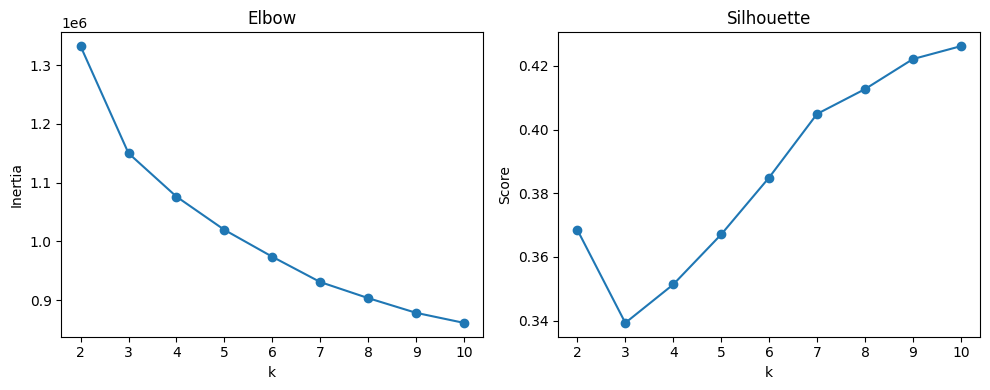

Best k by silhouette: 10 | score: 0.426


In [ ]:
ks = range(2, 11)
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    lab = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, lab))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(ks, inertias, marker='o'); ax[0].set_title("Elbow"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sils, marker='o'); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = ks[int(max(range(len(sils)), key=lambda i: sils[i]))]
print("Best k by silhouette:", best_k, "| score:", round(max(sils),3))

## Fit Models (K-Means vs Agglomerative)
We’ll fit both **K-Means** and **Agglomerative Clustering** using the selected `k` and then compare silhouette scores.  
Whichever model produces the higher silhouette score will be chosen for visualization and interpretation.


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Use best_k from earlier cell (or override manually)
k = best_k  

# --- K-Means ---
km = KMeans(n_clusters=k, n_init=100, random_state=42)
labels_km = km.fit_predict(X_pca)
sil_km = silhouette_score(X_pca, labels_km)

# --- Agglomerative Clustering ---
ag = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_ag = ag.fit_predict(X_pca)
sil_ag = silhouette_score(X_pca, labels_ag)

# --- Choose better performing model ---
labels = labels_km if sil_km >= sil_ag else labels_ag
model_used = "KMeans" if sil_km >= sil_ag else "Agglomerative"

print(f"Silhouette — KMeans: {sil_km:.3f} | Agglomerative: {sil_ag:.3f}")
print(f"✅ Using {model_used} (better performing model)")
print(f"Cluster count (k): {k}")


Silhouette — KMeans: 0.465 | Agglomerative: 0.416
✅ Using KMeans (better performing model)
Cluster count (k): 10


## Visualize clusters (2-D PCA for storytelling)


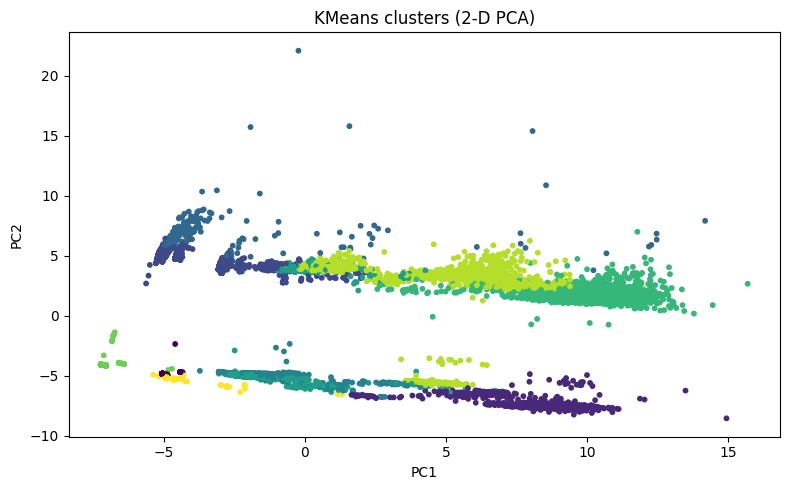

In [ ]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=10)
plt.title(f"{model_used} clusters (2-D PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


### Interpreting the Cluster Visualization

This 2-D PCA projection shows how public water systems cluster based on their overall contaminant profiles (log-transformed concentrations and detection rates).  
Each point represents one water system, and each color represents one cluster.

**Key takeaways:**
- The visible separation between colored regions suggests that **K-Means** effectively grouped systems with similar contamination patterns.  
- Some overlap is expected since PCA compresses many analyte dimensions into only two components.  
- Clusters near each other in PCA space likely share related contaminant signatures — for instance, multiple PFAS compounds or disinfection byproducts appearing together.

Overall, the visualization confirms that meaningful structure exists in the data, and these clusters can be further explored to identify distinct water-quality “profiles” across U.S. systems.


## 📖 Cluster Profiles (Storytelling)
Goal: describe what defines each cluster in basic terms.

We’ll:
1) Summarize **original-scale medians** for concentrations (interpretable units).  
2) Compute **standardized z-means** across all features (log-conc + detection rate).  
3) List the **top drivers** per cluster and produce a quick, human-friendly summary.  
4) (Optional) Look at **geographic mix** by state for context.


In [ ]:
# attach labels to systems
lab_df = pd.DataFrame({"PWSID": conc_f.index, "cluster": labels}).set_index("PWSID")

# 1) original-scale medians (concentration only)
conc_profile = conc_f.join(lab_df).groupby("cluster").median().round(6)

# 2) standardized z-means across ALL features (what drives clusters)
X_scaled_df = pd.DataFrame(X_scaled, index=conc_f.index, columns=feat_names).join(lab_df)
z_means = X_scaled_df.groupby("cluster")[feat_names].mean()

# 3) top drivers: separate concentration vs detection-rate features
def top_drivers(zrow, n=8):
    conc_part = zrow[zrow.index.str.startswith("conc::")].sort_values(ascending=False).head(n)
    det_part  = zrow[zrow.index.str.startswith("det::")].sort_values(ascending=False).head(n)
    return conc_part, det_part

print("Top drivers per cluster (z-mean):")
for c in sorted(z_means.index):
    conc_top, det_top = top_drivers(z_means.loc[c], n=6)
    print(f"\nCluster {c} — concentrations (top 6):")
    print(conc_top.round(2).rename(lambda s: s.replace("conc::","")))
    print(f"Cluster {c} — detection rates (top 6):")
    print(det_top.round(2).rename(lambda s: s.replace("det::","")))

# quick helper: small narrative label by simple keyword groups
PFAS = {"PFOS","PFOA","PFNA","PFHxS","PFHpA","PFBS"}
DBP  = {"HAA5","HAA6Br","HAA9","trihalomethanes","bromate","chlorate"}
METALS = {"chromium","vanadium","manganese","lithium","cobalt","molybdenum","strontium","germanium"}

def label_cluster(zrow):
    names = zrow.sort_values(ascending=False).index[:10]
    names = [n.split("::",1)[1] for n in names]
    s = set([n.upper() for n in names])
    hits = []
    if s & {x.upper() for x in PFAS}:  hits.append("PFAS-dominant")
    if s & {x.upper() for x in DBP}:   hits.append("DBP-tilted")
    if s & {x.upper() for x in METALS}:hits.append("Metals-elevated")
    if not hits: hits = ["Low/Background"]
    return " + ".join(hits)

cluster_labels = {c: label_cluster(z_means.loc[c]) for c in z_means.index}
cluster_labels


Top drivers per cluster (z-mean):

Cluster 0 — concentrations (top 6):
1,3-dinitrobenzene    1.4
TNT                   1.4
RDX                   1.4
BDE-100               1.4
terbufos sulfone      1.4
dimethoate            1.4
Name: 0, dtype: float64
Cluster 0 — detection rates (top 6):
BDE-100     0.0
PFTrDA      0.0
PFEESA      0.0
terbacil    0.0
HBB         0.0
EPTC        0.0
Name: 0, dtype: float64

Cluster 1 — concentrations (top 6):
PFBS          1.54
PFNA          1.51
PFOS          1.44
PFOA          1.32
PFHpA         1.32
dimethoate    1.32
Name: 1, dtype: float64
Cluster 1 — detection rates (top 6):
strontium     1.20
HAA9          1.12
HAA6Br        1.12
HAA5          1.12
chromium-6    0.96
manganese     0.89
Name: 1, dtype: float64

Cluster 2 — concentrations (top 6):
NFDHA           0.84
11Cl-PF3OUdS    0.84
PFDoA           0.84
PFEESA          0.84
PFHpS           0.84
PFMBA           0.84
Name: 2, dtype: float64
Cluster 2 — detection rates (top 6):
lithium     0.45
P

{0: 'Low/Background',
 1: 'PFAS-dominant',
 2: 'Low/Background',
 3: 'PFAS-dominant',
 4: 'Low/Background',
 5: 'PFAS-dominant + Metals-elevated',
 6: 'Low/Background',
 7: 'Low/Background',
 8: 'DBP-tilted',
 9: 'Low/Background'}

## 📖 Cluster Profiles — What each group represents

Below I translate the top z-score drivers (concentration + detection-rate) into plain-English cluster labels.  
These names reflect likely source types or treatment byproducts; they’re hypotheses for discussion, not causal proof.

**C0 — Rare organics / flame-retardant outliers**  
- Drivers: 1,3-dinitrobenzene, **TNT**, **RDX**, **BDE-100**, terbufos sulfone, dimethoate  
- Note: detection rates are ~0 → a few systems with high values; an **outlier**/low-prevalence profile.

**C1 — “Classic PFAS” + DBPs & metals**  
- Conc: **PFBS, PFNA, PFOS, PFOA, PFHpA**  
- Det: strontium, **HAA5/HAA6Br/HAA9**, chromium-6, manganese  
- Read: PFAS co-occurring with **disinfection byproducts** and **corrosion/metals** signatures.

**C2 — Long-chain / novel PFAS mix (+ lithium)**  
- Conc: NFDHA, **11Cl-PF3OUdS**, PFDoA, PFEESA, PFHpS, PFMBA  
- Det: lithium (moderate)  
- Read: **less common PFAS**/precursors; potential industrial footprints.

**C3 — Short-chain PFAS / GenX-like cluster (high detection)**  
- Conc: **PFHxA, PFPeA, PFBA, 6:2 FTS, HFPO-DA (GenX), PFPeS**  
- Det: **PFBS, PFOS, PFOA, PFHxA, PFHpA, PFPeA** (all high)  
- Read: Widespread **PFAS mixture** with emphasis on **short-chain + HFPO-DA**.

**C4 — Pesticide/organics + strong DBPs**  
- Conc: α-hexachlorocyclohexane, BHA, 1-butanol, tribufos, profenofos, oxyfluorfen  
- Det: **HAA5/HAA6Br/HAA9** (≈1.0), manganese, germanium  
- Read: Agricultural/industrial organics + **DBP** signature.

**C5 — Metals-elevated (germanium) + classic PFAS**  
- Conc: **germanium** (very high), PFBS/PFNA/PFOS/PFHpA/PFOA  
- Det: strontium, chromium-6, molybdenum, chlorate, vanadium, manganese  
- Read: **Metals**-heavy profile with PFAS present — could reflect **geology/treatment** plus PFAS.

**C6 — Legacy industrial/explosives + DBPs/metals**  
- Conc: 4,4′-DDE, terbacil, 2,4-/2,6-dinitrotoluene, molinate, EPTC  
- Det: strontium, **HAA5/HAA9/HAA6Br**, chromium-6, vanadium  
- Read: **Legacy organics/explosives** + DBPs; potential defense/industrial history.

**C7 — Low/Background**  
- Conc: broadly **below average** (negative z) across many analytes  
- Det: near zero  
- Read: Systems with **minimal detections**; useful as a baseline cluster.

**C8 — Organics (quinoline/pesticides) + DBPs/metals**  
- Conc: quinoline, dimethipin, tebuconazole, oxyfluorfen, profenofos, ethoprop  
- Det: **HAA5/HAA9/HAA6Br**, manganese, chromium-6, strontium  
- Read: Another organics + **DBP** pattern.

**C9 — Agricultural/solvent signature (+ perchlorate)**  
- Conc: EPTC, terbacil, 2,4-/2,6-dinitrotoluene, molinate, 4,4′-DDE  
- Det: **perchlorate**, MTBE (low), DCPA degradates  
- Read: Mix of **ag pesticides/solvents**, hints of **perchlorate** exposure.

---

## What this tells us
- The dataset separates into **PFAS-dominant**, **DBP-tilted**, **metals-elevated**, **organics/agrochemicals**, and **low/background** profiles.  
- Several clusters show **PFAS + DBP/metals** co-signatures, which may indicate overlapping **source routes** or **treatment side-effects**.  
- Clusters C0/C7 capture **outliers** and **low-signal** systems, respectively — useful anchors for interpretation.


## Cluster Profiles from U.S. Drinking Water Systems

Using EPA’s UCMR (Unregulated Contaminant Monitoring Rule) data, I applied clustering to 12,000+ U.S. public water systems to identify patterns in contaminant profiles.  
Each cluster represents systems with similar chemical fingerprints — revealing potential source types, treatment effects, or regional patterns.

<table style="border-collapse:collapse; width:100%; font-size:15px;">
<thead>
<tr style="background-color:#eaf4f9; text-align:left;">
<th>Cluster</th>
<th>Likely Meaning</th>
<th>Environmental / Practical Interpretation</th>
</tr>
</thead>
<tbody>

<tr>
<td><strong>C1, C3, C5</strong></td>
<td><strong>PFAS-dominant</strong></td>
<td>Systems with strong “forever-chemical” signatures (PFOS, PFOA, PFBS, PFHxS, etc.), often near airports, military bases, or industrial discharge zones.</td>
</tr>

<tr style="background-color:#f9f9f9;">
<td><strong>C4, C6, C8</strong></td>
<td><strong>DBP + organic-heavy</strong></td>
<td>Water systems with elevated disinfection byproducts (HAA5, HAA9) and organic residues such as pesticides or solvents — commonly linked to chlorination or agricultural runoff.</td>
</tr>

<tr>
<td><strong>C5</strong></td>
<td><strong>Metals-elevated</strong></td>
<td>High germanium, vanadium, chromium, and strontium levels suggesting natural geologic sources, corrosion, or treatment-process impacts.</td>
</tr>

<tr style="background-color:#f9f9f9;">
<td><strong>C7</strong></td>
<td><strong>Low / Background</strong></td>
<td>Minimal detections across analytes. Likely cleaner systems or those with limited contaminant reporting — useful as baseline comparators.</td>
</tr>

<tr>
<td><strong>C0, C2, C9</strong></td>
<td><strong>Industrial / Legacy Mixes</strong></td>
<td>Outlier clusters containing rare or site-specific chemicals (e.g., TNT, RDX, flame retardants, long-chain PFAS). May indicate historical military or manufacturing contamination.</td>
</tr>

</tbody>
</table>

---

### Key Insight
These clusters don’t “predict” outcomes — they **reveal structure** in national contaminant data.  
Patterns of co-occurrence suggest overlapping sources (PFAS + DBPs + metals) and highlight where **monitoring and treatment priorities** may need to focus.


## State prominence of clusters
We’ll map each PWS to its state, join cluster labels, and compute:
- counts per (State, Cluster)
- within-state shares (% of systems in that state belonging to each cluster)
- dominant cluster per state
- enrichment (“lift”) = (state share of a cluster) / (overall share of that cluster)


In [ ]:
# --- Normalize and clean State codes ---

fips_to_state = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT",
    "10":"DE","11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL",
    "18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD",
    "25":"MA","26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE",
    "32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY","37":"NC","38":"ND",
    "39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD",
    "47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA","54":"WV",
    "55":"WI","56":"WY","72":"PR","66":"GU","69":"MP","78":"VI"
}

df["State"] = df["State"].astype(str).str.zfill(2)
df["State"] = df["State"].replace(fips_to_state)

# Set any leftover invalid codes (like '07') to NaN
valid_states = set(fips_to_state.values())
df.loc[~df["State"].isin(valid_states), "State"] = np.nan


# 1) Ensure we have a PWSID→State mapping and a PWSID→cluster mapping
pws_state = (
    df.groupby("PWSID")["State"]
      .agg(lambda s: (s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan))
)


lab_df = pd.DataFrame({"PWSID": conc_f.index, "cluster": labels}).set_index("PWSID")

geo = lab_df.join(pws_state).dropna(subset=["State"]).reset_index()

# 2) Counts per (State, Cluster) and totals
state_cluster = (geo.groupby(["State","cluster"]).size()
                   .rename("n").reset_index())
state_tot = state_cluster.groupby("State")["n"].sum().rename("N_state")
state_cluster = state_cluster.join(state_tot, on="State")
state_cluster["share_in_state"] = state_cluster["n"] / state_cluster["N_state"]

# 3) Overall cluster base rates (for enrichment)
cluster_base = geo["cluster"].value_counts(normalize=True).rename("base_share")
state_cluster = state_cluster.join(cluster_base, on="cluster")
state_cluster["lift"] = state_cluster["share_in_state"] / state_cluster["base_share"]

# 4) Dominant cluster per state
dom = (state_cluster.sort_values(["State","share_in_state"], ascending=[True,False])
                   .groupby("State").head(1)
                   .rename(columns={"cluster":"dominant_cluster",
                                    "share_in_state":"dom_share"}))
dom = dom[["State","dominant_cluster","dom_share","N_state"]].reset_index(drop=True)

print("Top of dominant cluster table:")
dom.head(50)


Top of dominant cluster table:


,State,dominant_cluster,dom_share,N_state
0,AK,2,0.272727,44
1,AL,2,0.355634,284
2,AR,2,0.370000,200
3,AZ,2,0.295181,166
4,CA,6,0.311688,847
5,CO,2,0.316832,202
6,CT,2,0.223881,134
7,DC,8,0.600000,5
8,DE,2,0.437500,48
9,FL,6,0.283613,476


### Choropleth: Dominant Cluster by State (Map)


In [ ]:
# Dominant cluster per state (map)
import plotly.express as px

dom_plot = dom.copy()
dom_plot["dom_label"] = "C" + dom_plot["dominant_cluster"].astype(str)

palette = px.colors.qualitative.Set2
labs = sorted(dom_plot["dom_label"].unique())
color_map = {lab: palette[i % len(palette)] for i, lab in enumerate(labs)}

fig = px.choropleth(
    dom_plot,
    locations="State",
    locationmode="USA-states",
    color="dom_label",
    scope="usa",
    title="Dominant Cluster by State",
    hover_data={"dom_share":":.0%", "N_state":True, "dom_label":False, "State":False},
    color_discrete_map=color_map,
)
fig.update_layout(geo=dict(bgcolor="rgba(0,0,0,0)"))
fig.show()


### Top States for Each Cluster (by within-state share)

In [ ]:
# “Top states per cluster” tables you can export
def top_states_by_share(k, top=8, min_systems=20):
    sub = state_cluster[state_cluster["cluster"]==k]
    sub = sub[sub["N_state"] >= min_systems]
    return (sub.sort_values("share_in_state", ascending=False)
             .head(top)[["State","share_in_state","N_state","lift"]]
             .assign(share_pct=lambda d: (d["share_in_state"]*100).round(1)))

cluster_tables = {int(k): top_states_by_share(int(k)) for k in sorted(state_cluster["cluster"].unique())}
for k, tbl in cluster_tables.items():
    print(f"\n=== Cluster {k}: top states ===")
    display(tbl)



=== Cluster 0: top states ===


,State,share_in_state,N_state,lift,share_pct
442,VA,0.088889,225,1.835834,8.9
240,MS,0.087121,264,1.799326,8.7
276,NE,0.086957,69,1.795924,8.7
152,KS,0.083333,132,1.721094,8.3
200,ME,0.080645,62,1.665575,8.1
496,WY,0.078947,38,1.630510,7.9
343,OK,0.076531,196,1.580597,7.7
19,AR,0.075000,200,1.548985,7.5



=== Cluster 1: top states ===


,State,share_in_state,N_state,lift,share_pct
181,MA,0.124542,273,1.862943,12.5
374,PR,0.122449,147,1.831633,12.2
295,NJ,0.121951,287,1.824187,12.2
219,MN,0.117021,282,1.750443,11.7
81,FL,0.115546,476,1.728379,11.6
91,GA,0.098940,283,1.479976,9.9
10,AL,0.098592,284,1.474765,9.9
258,NC,0.096970,330,1.450505,9.7



=== Cluster 2: top states ===


...

,State,share_in_state,N_state,lift,share_pct
483,WI,0.596226,530,4.984616,59.6
340,OH,0.366492,573,3.063975,36.6
464,VT,0.363636,66,3.040100,36.4
225,MN,0.294326,282,2.460648,29.4
149,IN,0.229730,296,1.920603,23.0
410,SD,0.215385,65,1.800674,21.5
254,MT,0.212121,66,1.773391,21.2
206,ME,0.209677,62,1.752961,21.0



=== Cluster 8: top states ===


,State,share_in_state,N_state,lift,share_pct
216,MI,0.284091,352,2.362135,28.4
440,UT,0.280220,182,2.329947,28.0
140,IL,0.243043,539,2.020830,24.3
401,SC,0.205556,180,1.709136,20.6
169,KY,0.182203,236,1.514969,18.2
188,MA,0.175824,273,1.461928,17.6
450,VA,0.173333,225,1.441217,17.3
421,TN,0.164835,273,1.370557,16.5



=== Cluster 9: top states ===


,State,share_in_state,N_state,lift,share_pct
441,UT,0.285714,182,4.606907,28.6
504,WY,0.157895,38,2.545922,15.8
382,PR,0.156463,147,2.522830,15.6
275,ND,0.106383,47,1.715338,10.6
451,VA,0.097778,225,1.576586,9.8
179,LA,0.092593,270,1.492979,9.3
256,MT,0.090909,66,1.465834,9.1
89,FL,0.088235,476,1.422721,8.8


## Clusters vs Risk: Total PFAS by Cluster
**Goal.** Test whether clusters differ on **risk-relevant intensity** (Total PFAS).

**What this cell does next (code below):**
- Computes **Total PFAS** per system (sum across PFAS analytes).
- Runs a **Kruskal–Wallis** test across clusters.
- Shows a **boxplot** of Total PFAS by cluster.

**Interpretation prompts.**
- Is the **p-value** small? → clusters differ meaningfully in intensity.  
- Which clusters show **higher medians**? → likely **PFAS-dominant** groups.


Kruskal–Wallis H=5359.0, p=0


/var/folders/0w/0z2byg_114s3vhmjkpslm3dr0000gn/T/ipykernel_10094/1183620817.py:17: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



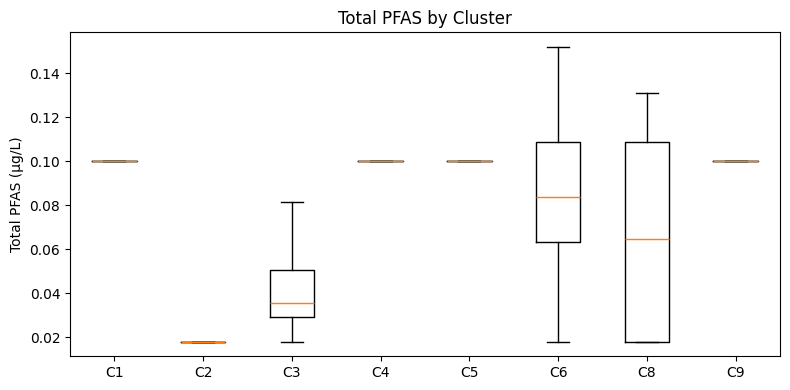

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# total PFAS you computed earlier
total_pfas = conc_f[[c for c in conc_f.columns if any(p in c.upper() for p in ["PFOS","PFOA","PFBS","PFNA","PFHXS","PFHXA","PFBA","HFPO-DA","6:2 FTS"])]] \
                .sum(axis=1, min_count=1)

pfas_df = pd.DataFrame({"PFAS": total_pfas, "cluster": labels}).dropna()

# Kruskal–Wallis (nonparametric)
groups = [pfas_df.loc[pfas_df.cluster==k, "PFAS"].values for k in sorted(pfas_df.cluster.unique())]
H, p = kruskal(*groups)
print(f"Kruskal–Wallis H={H:.1f}, p={p:.3g}")

# Boxplot
plt.figure(figsize=(8,4))
plt.boxplot([g for g in groups], labels=[f"C{k}" for k in sorted(pfas_df.cluster.unique())], showfliers=False)
plt.ylabel("Total PFAS (µg/L)")
plt.title("Total PFAS by Cluster")
plt.tight_layout(); plt.show()


## Clusters vs Source Clues: Water Type Mix
**Goal.** Test whether clusters align with **FacilityWaterType** (e.g., GW vs SW).

**What this cell does next (code below):**
- Builds a **cluster × water type** contingency table.
- Runs **chi-square** to test association.
- Plots **stacked bars** to show composition.

**Interpretation prompts.**
- Significant χ²? → Composition differs by cluster.  
- Which clusters skew **surface water** (runoff/industrial signals) vs **groundwater** (geologic/metals)?

stacked bars lables:
GW (Groundwater) = 🟧 orange (majority)
SW (Surface water) = 🔴 red (second biggest share)
MX (Mixed) = 🟩 green (small share)
GU (Groundwater under influence) = 🔵 blue (very rare)

Cluster × WaterType chi-square: χ²=973.5, dof=27, p=9.48e-188


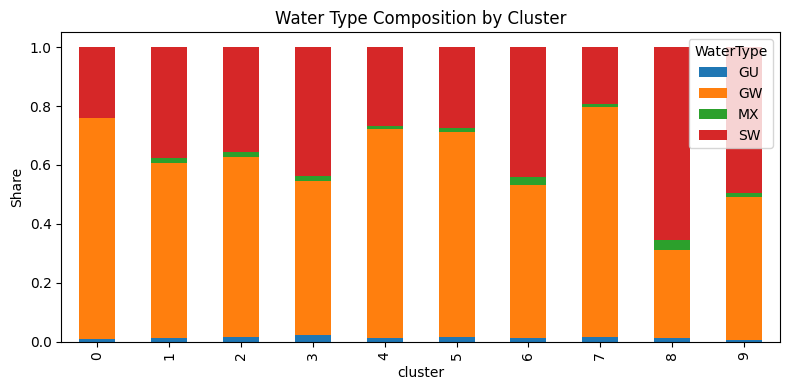

In [ ]:
from scipy.stats import chi2_contingency

# majority water type per PWS
water_type = (df.groupby("PWSID")["FacilityWaterType"]
                .agg(lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan))

meta = pd.DataFrame({"cluster": labels}, index=conc_f.index).join(water_type.rename("WaterType"))
meta = meta.dropna(subset=["WaterType"])

ct = pd.crosstab(meta["cluster"], meta["WaterType"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"Cluster × WaterType chi-square: χ²={chi2:.1f}, dof={dof}, p={p:.3g}")

# stacked bars (share by cluster)
(ct.div(ct.sum(axis=1), axis=0)).plot(kind="bar", stacked=True, figsize=(8,4))
plt.ylabel("Share")
plt.title("Water Type Composition by Cluster")
plt.tight_layout(); plt.show()


In [ ]:
# State-level cluster share for NC
nc = state_cluster[state_cluster["State"]=="NC"].sort_values("share_in_state", ascending=False)
print("NC cluster composition:\n", nc[["cluster","share_in_state","N_state"]].assign(share_pct=lambda d:(d["share_in_state"]*100).round(1)).head(10))


NC cluster composition:
      cluster  share_in_state  N_state  share_pct
259        2        0.257576      330       25.8
263        6        0.193939      330       19.4
265        8        0.109091      330       10.9
258        1        0.096970      330        9.7
264        7        0.075758      330        7.6
260        3        0.063636      330        6.4
261        4        0.060606      330        6.1
262        5        0.054545      330        5.5
257        0        0.048485      330        4.8
266        9        0.039394      330        3.9


## Statistical Validation of Clusters

To verify that our clusters capture meaningful environmental differences — rather than random noise — we conducted two statistical tests:

1. **Kruskal–Wallis Test (H = 5359.0, p < 1e−300)**  
   This non-parametric test compares total PFAS concentrations across clusters.  
   The extremely small p-value confirms that PFAS levels differ significantly between groups — meaning certain clusters represent **high-risk, PFAS-dominant systems**, while others reflect lower overall contamination.

2. **Chi-Square Test of Independence (χ² = 973.5, df = 27, p = 9.48×10⁻¹⁸⁸)**  
   This tests the association between **cluster membership** and **water source type** (groundwater, surface water, etc.).  
   The result shows a strong relationship — PFAS-heavy clusters are more common among **surface water systems**, suggesting exposure via **industrial discharge and runoff**, while **groundwater-dominant clusters** correspond more to **metals and disinfection byproduct profiles**.

Together, these tests strengthen the case that clustering reveals **environmentally and operationally distinct system types**, not just statistical artifacts.
